In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import urllib.request
import zipfile
import os

# Download TrashNet garbage dataset
dataset_url = "https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip"

print("Downloading dataset (around 40 MB)...")
urllib.request.urlretrieve(dataset_url, "dataset.zip")

print("Extracting files...")
with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

# Path to images
DATASET_PATH = "dataset/dataset-resized"

# Check the classes inside
classes = [f for f in os.listdir(DATASET_PATH) if not f.startswith('.')]
print("Success! Classes found:", classes)

Extracting files...
Success! Classes found: ['trash', 'paper', 'cardboard', 'metal', 'plastic', 'glass']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32

# Training generator with Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 80% training, 20% validation
)

# Load training set (80%)
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load validation set (20%)
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Number of classes: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# 1. Load InceptionV3 base
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)

# 2. Freeze the base layers
base_model.trainable = False

# 3. Add custom classification head on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# 4. Construct complete model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("InceptionV3 Model successfully built and compiled!")
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
InceptionV3 Model successfully built and compiled!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,328,870 (85.18 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Save the best model weights
checkpoint = ModelCheckpoint(
    'best_inception_garbage_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Dynamically adjust learning rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

EPOCHS = 100

print("Starting 100 epochs of training on GPU...")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr]
)

Starting 100 epochs of training on GPU...
Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.9485 - loss: 0.1633
Epoch 1: val_accuracy improved from None to 0.82306, saving model to best_inception_garbage_model.keras

Epoch 1: finished saving model to best_inception_garbage_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 913ms/step - accuracy: 0.9447 - loss: 0.1604 - val_accuracy: 0.8231 - val_loss: 0.5552 - learning_rate: 1.0000e-06
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9489 - loss: 0.1639
Epoch 2: val_accuracy improved from 0.82306 to 0.83499, saving model to best_inception_garbage_model.keras

Epoch 2: finished saving model to best_inception_garbage_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 878ms/step - accuracy: 0.9476 - loss: 0.1712 - val_accuracy: 0.8350 - val_loss: 0.5454 - learning_rate: 1.0000e-06
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.9382 - loss: 0.1807
Epoch 3: val_accuracy did not improve from 0.83499
64/

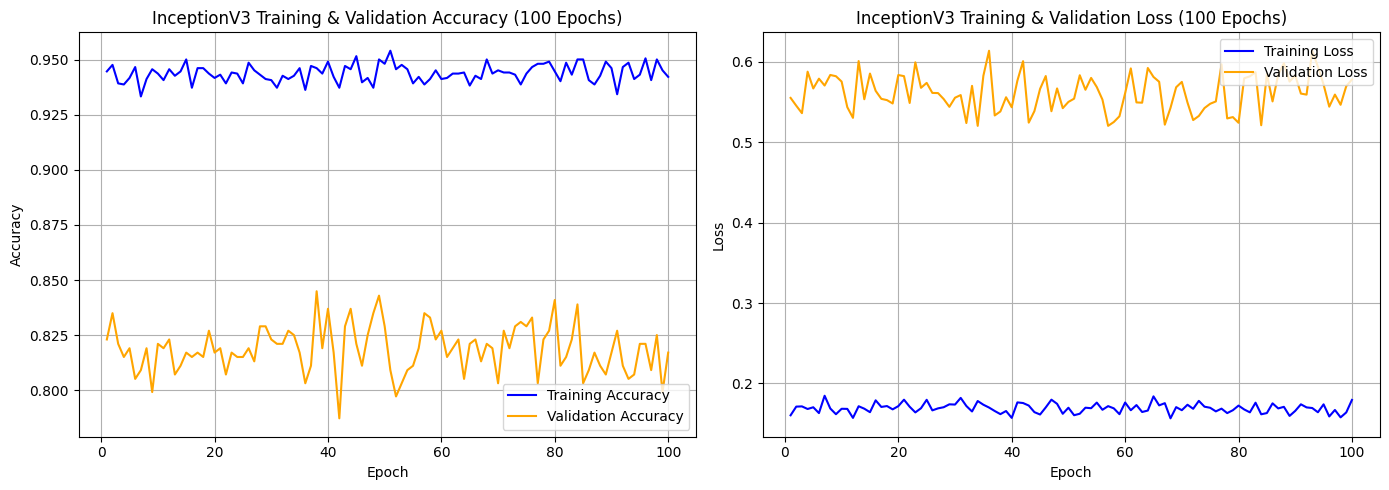

Graph saved as 'accuracy_loss_graph.png'


In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('InceptionV3 Training & Validation Accuracy (100 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('InceptionV3 Training & Validation Loss (100 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('accuracy_loss_graph.png', dpi=300)
plt.show()
print("Graph saved as 'accuracy_loss_graph.png'")

16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step
Classification Report:

              precision    recall  f1-score   support

   cardboard       0.95      0.78      0.86        80
       glass       0.84      0.86      0.85       100
       metal       0.77      0.85      0.81        82
       paper       0.83      0.94      0.88       118
     plastic       0.81      0.77      0.79        96
       trash       0.60      0.44      0.51        27

    accuracy                           0.83       503
   macro avg       0.80      0.77      0.78       503
weighted avg       0.83      0.83      0.82       503



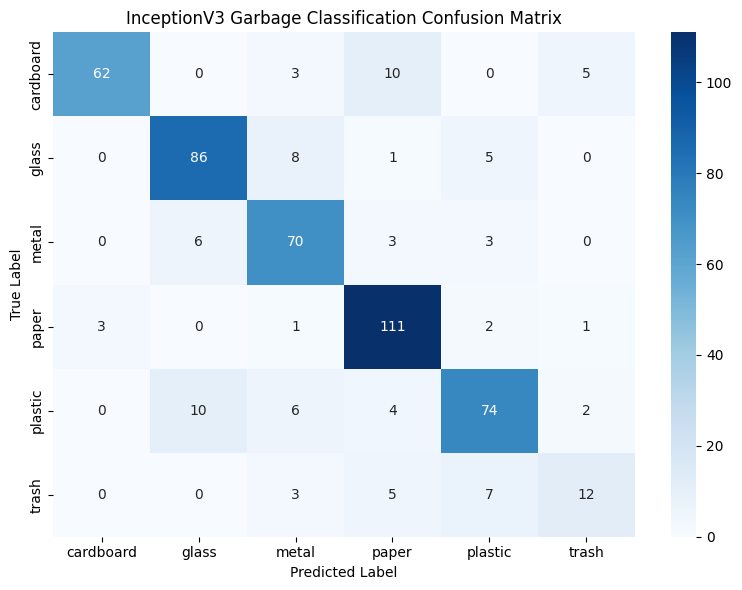

Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Load best saved weights
best_model = tf.keras.models.load_model('best_inception_garbage_model.keras')

# Predict on validation data
val_generator.reset()
y_pred_probs = best_model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# Labels
target_names = list(val_generator.class_indices.keys())

# Print Classification Report (Precision, Recall, F1-score)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('InceptionV3 Garbage Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

Upload an image of garbage (paper, plastic, glass, etc.):


Saving garbage.jpeg to garbage.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


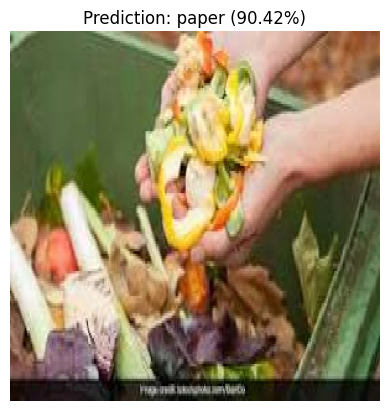

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

print("Upload an image of garbage (paper, plastic, glass, etc.):")
uploaded = files.upload()

for filename in uploaded.keys():
    # Load and preprocess
    img = image.load_img(filename, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Predict
    preds = best_model.predict(img_batch)[0]
    pred_idx = np.argmax(preds)
    pred_class = target_names[pred_idx]
    confidence = preds[pred_idx] * 100

    # Display result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {pred_class} ({confidence:.2f}%)")
    plt.show()

In [ ]:
# 1. Install gradio
!pip install -q gradio

import gradio as gr
import tensorflow as tf
from PIL import Image
import numpy as np

# 2. Load your best saved model
model = tf.keras.models.load_model('best_inception_garbage_model.keras')

# Class labels
labels = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# 3. Define prediction function for the website
def classify_garbage(img):
    # Resize image to 299x299 for InceptionV3
    img = img.resize((299, 299))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)[0]

    # Return dictionary of class: probability
    return {labels[i]: float(prediction[i]) for i in range(len(labels))}

# 4. Launch the web UI
demo = gr.Interface(
    fn=classify_garbage,
    inputs=gr.Image(type="pil", label="Upload Garbage Image"),
    outputs=gr.Label(num_top_classes=3, label="Top Predictions"),
    title="Automated Garbage Classification System",
    description="Upload a photo of waste/garbage to classify it using our trained InceptionV3 Deep Learning model."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9afaca8108c41983c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
from google.colab import drive
import shutil

drive.mount('/content/drive')
# Copies the trained model into your Google Drive root folder
shutil.copy('best_inception_garbage_model.keras', '/content/drive/MyDrive/best_inception_garbage_model.keras')
print("Model saved permanently to Google Drive!")

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: 'best_inception_garbage_model.keras'

In [2]:
# 1. Connect to your Google Drive where the model is saved
from google.colab import drive
print("Connecting to Drive...")
drive.mount('/content/drive')

# 2. Install Gradio for the web interface
!pip install -q gradio

import gradio as gr
import tensorflow as tf
from PIL import Image
import numpy as np

# 3. Load your trained InceptionV3 model directly from Drive
model_path = '/content/drive/MyDrive/best_inception_garbage_model.keras'
print("Loading InceptionV3 model...")
model = tf.keras.models.load_model(model_path)

labels = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

def classify_garbage(img):
    # InceptionV3 requires 299x299 RGB images normalized to [0, 1]
    img = img.resize((299, 299))
    img_array = np.array(img).astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]
    return {labels[i]: float(predictions[i]) for i in range(len(labels))}

# 4. Launch the web UI
demo = gr.Interface(
    fn=classify_garbage,
    inputs=gr.Image(type="pil", label="Upload Garbage Photo"),
    outputs=gr.Label(num_top_classes=3, label="Detected Category"),
    title="Garbage Classification AI (InceptionV3)",
    description="Trained for 100 Epochs on TrashNet. Upload an image to classify."
)

demo.launch(share=True)

Connecting to Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading InceptionV3 model...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://554395db5742858de3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import tensorflow as tf
from PIL import Image
import numpy as np

# Loads the model directly from your Google Drive
model = tf.keras.models.load_model('/content/drive/MyDrive/best_inception_garbage_model.keras')
labels = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

def classify_garbage(img):
    img = img.resize((299, 299))
    img_array = np.array(img).astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)[0]
    return {labels[i]: float(prediction[i]) for i in range(len(labels))}

print("Model loaded and ready!")

Model loaded and ready!


In [ ]:
!pip install -q gradio
import gradio as gr

demo = gr.Interface(
    fn=classify_garbage,
    inputs=gr.Image(type="pil", label="Upload Garbage Image"),
    outputs=gr.Label(num_top_classes=3, label="Predicted Class"),
    title="Garbage Classification AI (InceptionV3)",
    description="100 Epochs InceptionV3 Model"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d37184b06769ad0627.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
